In [7]:
import pandas as pd
import numpy as np
from itertools import product
import matplotlib.pyplot as plt

# 사전 설치 필수: pip install linearmodels
from linearmodels.panel import PanelOLS

file_bank = r"C:\Users\dahye\OneDrive\바탕 화면\IM뱅크 교육\통계프로젝트\data.xlsx"
file_customs = r"C:\Users\dahye\OneDrive\바탕 화면\IM뱅크 교육\통계프로젝트\export_region.csv"

df_bank = pd.read_excel(file_bank)
df_customs = pd.read_csv(file_customs, encoding='utf-8')

##### 문자형으로 저장된 수출입 실적 금액을 숫자형으로 변환, 결측치를 0으로 처리 | 금액이 0보다 크거나 거래 건수가 존재하는 경우 조건을 True로 판별 -> 해당 월에 외환 거래가 하나라도 있으면 1, 없으면0-> 당월 외환실적 더미 컬럼 생성

In [8]:
df_bank['외환_수출실적금액'] = pd.to_numeric(df_bank['외환_수출실적금액'], errors='coerce').fillna(0)
df_bank['외환_수입실적금액'] = pd.to_numeric(df_bank['외환_수입실적금액'], errors='coerce').fillna(0)

has_export_amt = df_bank['외환_수출실적금액'] > 0
has_import_amt = df_bank['외환_수입실적금액'] > 0
has_export_cnt = df_bank['외환_수출실적거래건수'].notna() & (df_bank['외환_수출실적거래건수'] != '0건')
has_import_cnt = df_bank['외환_수입실적거래건수'].notna() & (df_bank['외환_수입실적거래건수'] != '0건')

df_bank['당월_외환실적'] = (has_export_amt | has_import_amt | has_export_cnt | has_import_cnt).astype(int)

##### 기준년월을 실제 시간 객체로 변환하여 인덱스로 설정, 이후 groupby와 rolling('365D')를 결합하여 당월을 제외한 직전 365일 내에 당월_외환실적의 값이 1(실적이 한번이라도 있는)법인만 과거1년_외환실적보유컬럼에 1로 표기 ->이 값이 1인 기업만 최종 처치군으로 확정

###### 3년 전에 딱 한번 수출해놓고 지금 내수만 하는 가짜 수출기업을 걸러냄

###### 데이터의 초기시점(202301)에는 과거 1년치 누적 데이터가 없어서 필터링 불안정할 수 있음

In [9]:
df_bank['기준년월'] = df_bank['기준년월'].astype(str)
df_bank['기준년월_dt'] = pd.to_datetime(df_bank['기준년월'], format='%Y%m')

df_bank = df_bank.sort_values(['법인ID', '기준년월_dt'])
df_bank = df_bank.set_index('기준년월_dt')

df_bank['과거1년_외환실적보유'] = df_bank.groupby('법인ID')['당월_외환실적'].transform(
    lambda x: x.shift(1).rolling('365D', min_periods=1).max()
)
df_bank = df_bank.reset_index()

df_bank = df_bank[df_bank['과거1년_외환실적보유'] == 1].copy()
exposed_firms = df_bank['법인ID'].unique()

##### 관세청 데이터의 연월 컬럼을 문자열로 변환 | 독립된 충격 데이터프레임 만든 후 대구은행 데이터와 원활하게 조인하기 위해 지역 컬럼 이름을 사업장_시도로 바꾸고 결측치가 있는 행 제거

In [10]:
df_customs['기준년월'] = df_customs['ym'].astype(str)

df_shock = df_customs[['region', '기준년월', 'yoy_exp_amt']].copy()
df_shock.rename(columns={'region': '사업장_시도', 'yoy_exp_amt': 'export_shock'}, inplace=True)
df_shock.dropna(subset=['export_shock'], inplace=True)


##### 처치군 법인 목록과 전체 연월 목록을 데키라트 곱하여 관측 누락이 없는 패널 뼈대를 만듦
##### 지역별 수출 충격, 업종 정보, 예금 잔액을 조인으로 병합하고 결측치를 Nan으로 둔 상태에서 log1p를 씌움

###### 쉬운 설명: 데이터가 중간중간 이빨이 빠져 있다고 해서 냅다 "0원"으로 채워버리면, 멀쩡히 돈이 있던 회사가 갑자기 파산한 것처럼 데이터가 왜곡됩니다. 그래서 아예 캘린더 전체를 새로 쫙 깔아놓고, 관측 안 된 달은 빈칸(결측치)으로 얌전히 놔두는 방식으로 조립한 겁니다.

###### 주의할 점: 빈칸을 그대로 두었기 때문에 나중에 회귀분석을 돌릴 때 이 빠진 달들은 계산에서 자연스럽게 제외됩니다. 이때 계좌를 해지하고 폐업해 버린 한계 기업들이 분석에서 빠지게 되는 '생존 편향'이 발생할 수 있습니다.

In [11]:
all_months = sorted(df_bank['기준년월'].unique())
df_grid = pd.DataFrame(list(product(exposed_firms, all_months)), columns=['법인ID', '기준년월'])

# 업종_중분류 추가 병합
firm_info = df_bank.dropna(subset=['사업장_시도', '업종_중분류']).groupby('법인ID')[['사업장_시도', '업종_중분류']].last().reset_index()
df_grid = pd.merge(df_grid, firm_info, on='법인ID', how='left')
df_grid = pd.merge(df_grid, df_shock, on=['사업장_시도', '기준년월'], how='left')

bank_subset = df_bank[['법인ID', '기준년월', '거치식예금잔액', '적립식예금잔액']]
df_merged = pd.merge(df_grid, bank_subset, on=['법인ID', '기준년월'], how='left')

df_merged['log_거치식'] = np.log1p(df_merged['거치식예금잔액'])
df_merged['log_적립식'] = np.log1p(df_merged['적립식예금잔액'])

##### 오염되지 않은 원본 잔액을 기준으로 해당 법인의 전체 분석 기간 내 예금 최댓값이 0을 초과하는지 검사 -> 이를 통해 한번이라도 계좌를 보유한 법인 리스트를 거치식과 적립식 각각 따로 추출하여 df_time과 df_install이라는 데이터프레임으로 설정

In [12]:
valid_time_firms = df_merged.groupby('법인ID')['거치식예금잔액'].max()
valid_time_firms = valid_time_firms[valid_time_firms > 0].index

valid_install_firms = df_merged.groupby('법인ID')['적립식예금잔액'].max()
valid_install_firms = valid_install_firms[valid_install_firms > 0].index

df_time = df_merged[df_merged['법인ID'].isin(valid_time_firms)].copy()
df_install = df_merged[df_merged['법인ID'].isin(valid_install_firms)].copy()

##### 문자열로 되어 있던 기준년월을 판다스의 시계열 객체로 변환 후 법인ID와 기준년월을 기준으로 오름차순 이 두 변수를 데이터프레임의 다중 인덱스로 고정 -> 패널 회귀분석 라이브러리가 인식할 수 있는 구조

###### 주의할 점: 여기서 sort_values(정렬) 과정을 빼먹으면 절대 안 됩니다. 정렬이 안 된 상태로 다음 단계(회귀분석)로 넘어가면, '1달 전 데이터'를 가져오는 shift() 함수가 엉뚱한 기업의 장부나 뒤죽박죽된 달의 잔액을 끌고 오는 대참사가 발생합니다. (현재 코드는 정렬 기준이 완벽하게 들어가 있으므로 안전합니다.)

In [13]:
df_time['기준년월'] = pd.to_datetime(df_time['기준년월'], format='%Y%m')
df_time = df_time.sort_values(by=['법인ID', '기준년월']).set_index(['법인ID', '기준년월'])

df_install['기준년월'] = pd.to_datetime(df_install['기준년월'], format='%Y%m')
df_install = df_install.sort_values(by=['법인ID', '기준년월']).set_index(['법인ID', '기준년월'])

##### 국소투영법 : 현재 달 대비 h개월후의 예금 변동량을 매 시점마다 새로 구하여 종속변수로 삼음 하락 국면 더미와 수출 충격을 곱한 교호작용 변수를 넣어 투입, PanelOLS를 통해 법인/시간 고정효과를 통제하고 자유도 부족으로 에러날 경루 h시점 스킵

##### 한계점: 클러스터 표준오차(Clustered SE)를 사용하므로 표본(법인 수)이 30개 미만인 극소형 업종에 적용하면 오차를 실제보다 작게 추정하여 가짜 유의성(1종 오류)을 뱉어낼 위험이 큽니다.

In [14]:
def run_local_projections_asymmetry_panel(data, dep_var, shock_var, max_h=12):
    results = []
    for h in range(max_h + 1):
        y_forward = data.groupby(level=0)[dep_var].shift(-h)
        y_lag = data.groupby(level=0)[dep_var].shift(1)
        data[f'delta_{dep_var}_h{h}'] = y_forward - y_lag

        reg_data = data[[f'delta_{dep_var}_h{h}', shock_var]].dropna()
        if reg_data.empty:
            continue

        lower_bound = reg_data[f'delta_{dep_var}_h{h}'].quantile(0.01)
        upper_bound = reg_data[f'delta_{dep_var}_h{h}'].quantile(0.99)
        reg_data[f'delta_{dep_var}_h{h}'] = reg_data[f'delta_{dep_var}_h{h}'].clip(lower_bound, upper_bound)

        reg_data['const'] = 1  
        reg_data['down_dummy'] = (reg_data[shock_var] < 0).astype(int)
        reg_data['interaction'] = reg_data[shock_var] * reg_data['down_dummy']

        mod = PanelOLS(
            dependent=reg_data[f'delta_{dep_var}_h{h}'],
            exog=reg_data[['const', shock_var, 'down_dummy', 'interaction']],
            entity_effects=True, #개체 교정효과 : 법인ID 
            time_effects=True     #시간 교정효과 : 기준년월
        )

        try:
            res = mod.fit(cov_type='clustered', cluster_entity=True)
        except ZeroDivisionError:
            continue
        except Exception:
            continue

        shock_coef = res.params[shock_var]
        interaction_coef = res.params['interaction']
        down_effect = shock_coef + interaction_coef

        cov_mat = res.cov
        if shock_var in cov_mat.columns and 'interaction' in cov_mat.columns:
            var_base = cov_mat.loc[shock_var, shock_var]
            var_int = cov_mat.loc['interaction', 'interaction']
            cov_base_int = cov_mat.loc[shock_var, 'interaction']
            se_down = np.sqrt(var_base + var_int + 2 * cov_base_int)
        else:
            se_down = np.nan

        results.append({
            'h': h,
            'coef': down_effect,
            'se': se_down,
            'p_value_interaction': res.pvalues['interaction']
        })
    return pd.DataFrame(results)

[업종별 거치식/적립식 예금 하방 비대칭성 검정 진행 중...]

[업종별 하락 국면 거치식 예금 반응 요약표 (* p<0.1, ** p<0.05)]
--------------------------------------------------------------------------------
                         업종명  법인수    h=3 계수 h=3 p-value   h=6 계수 h=6 p-value    h=12 계수 h=12 p-value
                 도매 및 상품 중개업   28  -0.0301        0.552 0.0168 *       0.056    0.0103         0.280
              기타 기계 및 장비 제조업   21  -0.0084        0.174 -0.0813        0.101 -0.2685 **        0.012
              섬유제품 제조업; 의복제외   11   0.0051        0.416  0.0011        0.364   -0.0129         0.186
              자동차 및 트레일러 제조업   16 0.0438 **       0.017  0.0582        0.383   -0.0197         0.550
                   1차 금속 제조업   24  -0.0068        0.964 -0.0139        0.559   -0.0722         0.182
     화학물질 및 화학제품 제조업; 의약품 제외   10   0.0580        0.381 -0.0425        0.238    0.1123         0.341
      금속가공제품 제조업; 기계 및 가구 제외   15  -0.0160        0.193 -0.0407        0.165   -0.0752         0.458
                     식료품 제조

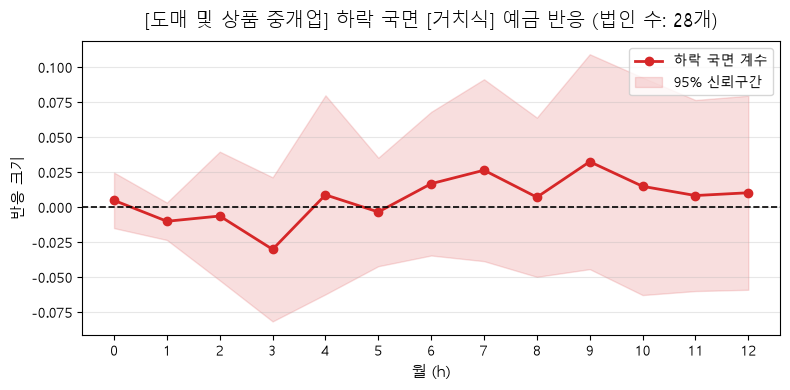

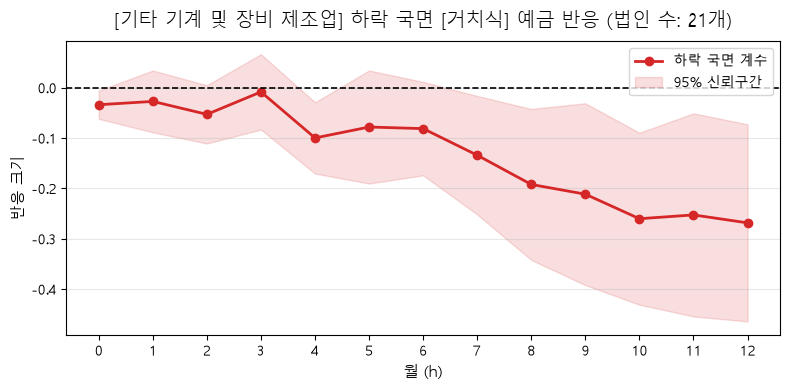

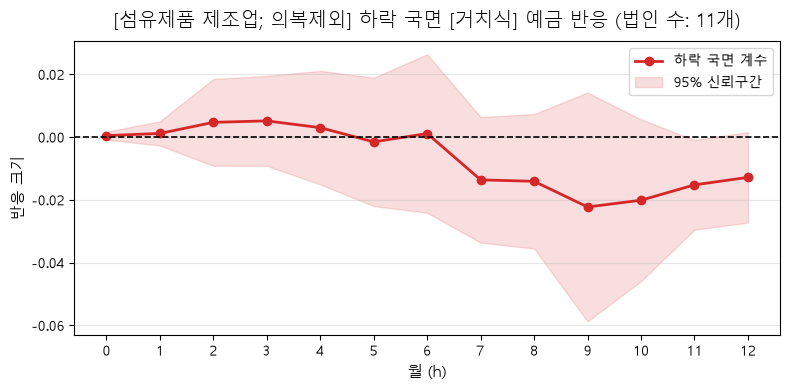

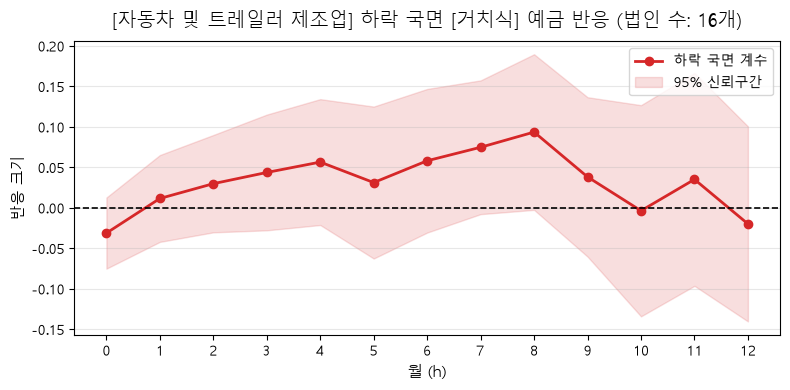

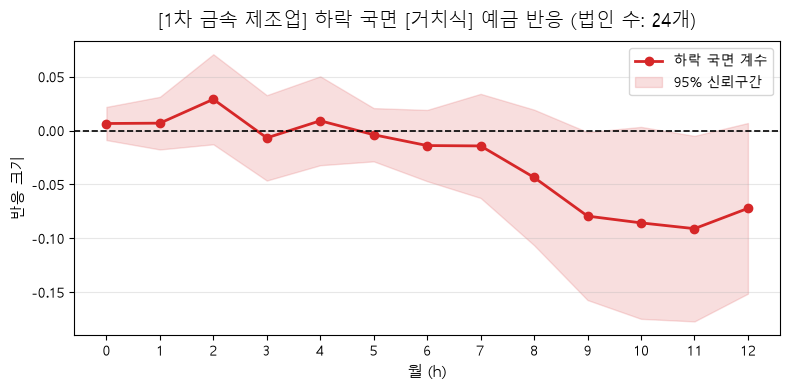

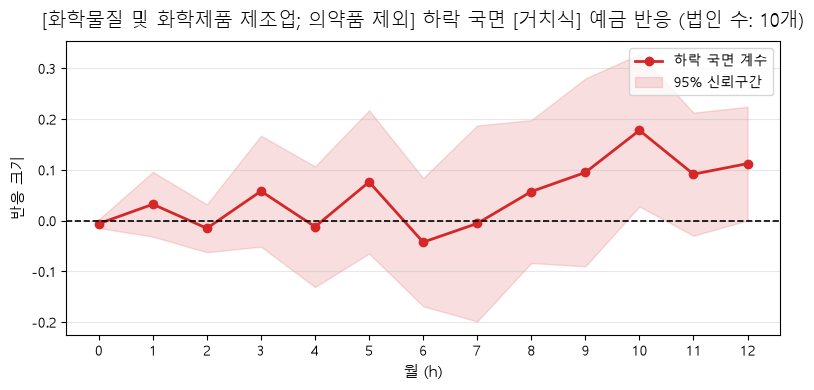

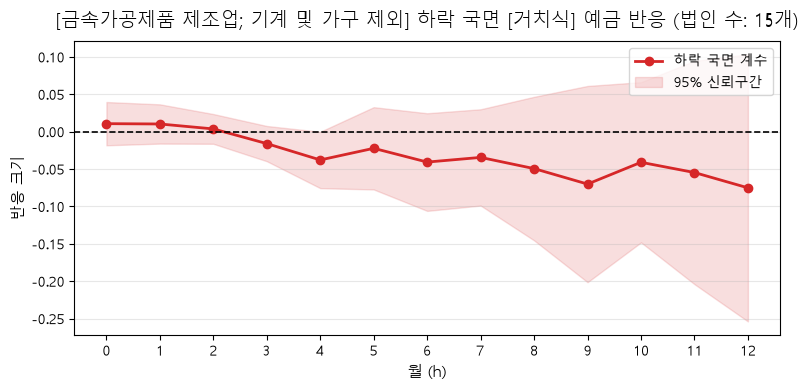

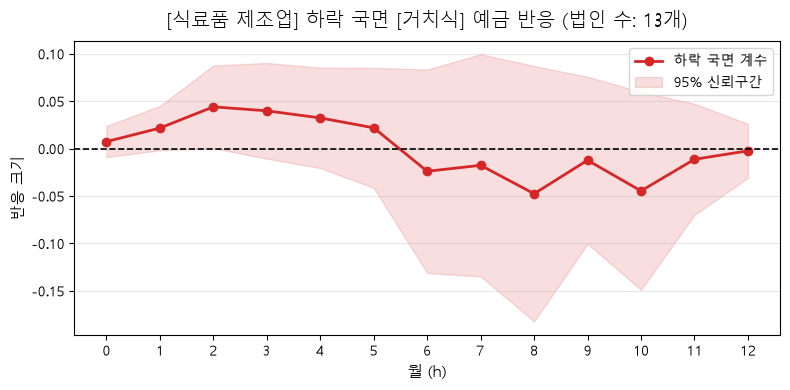

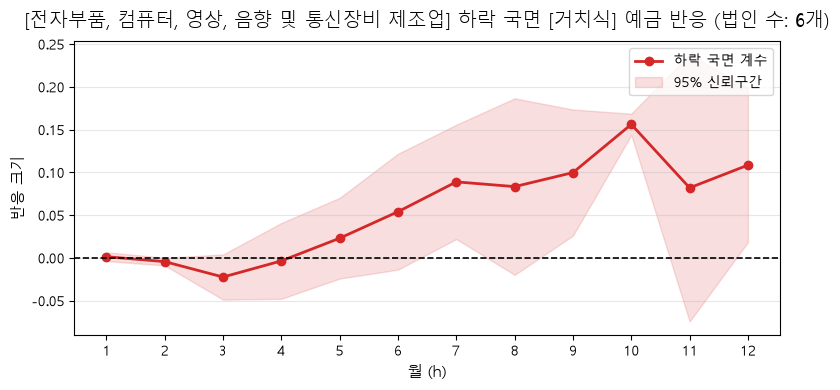


[업종별 충격반응함수(IRF) 시각화 - 적립식 예금]


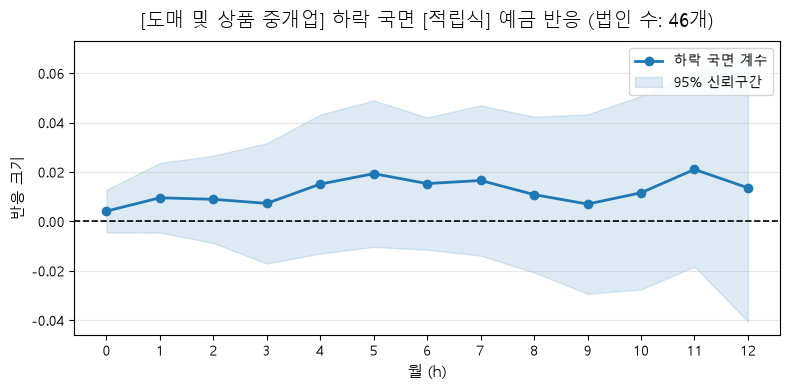

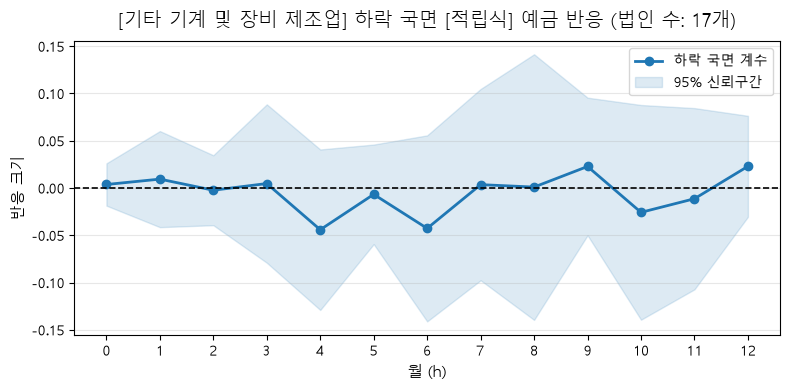

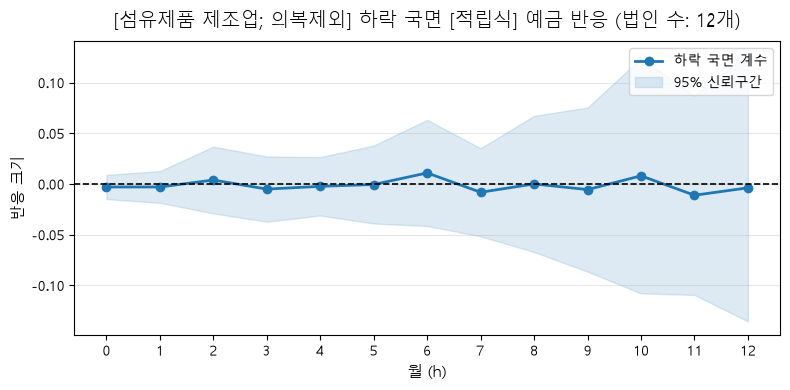

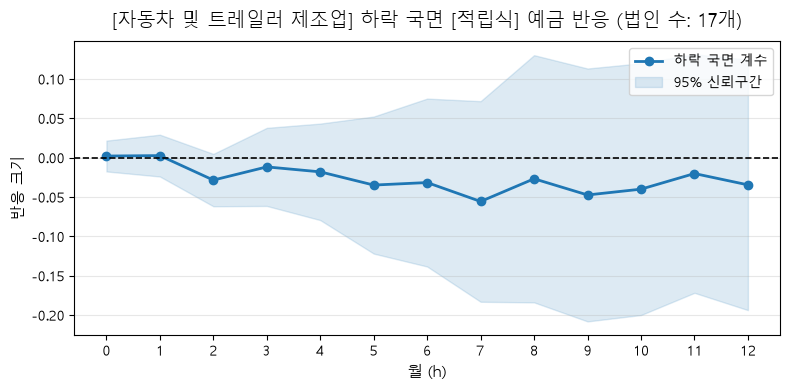

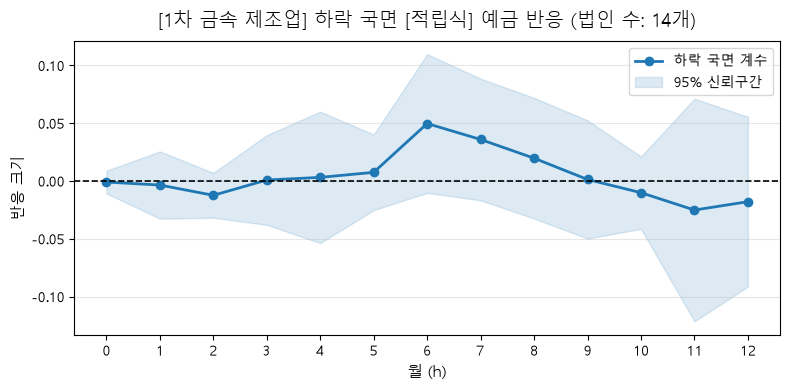

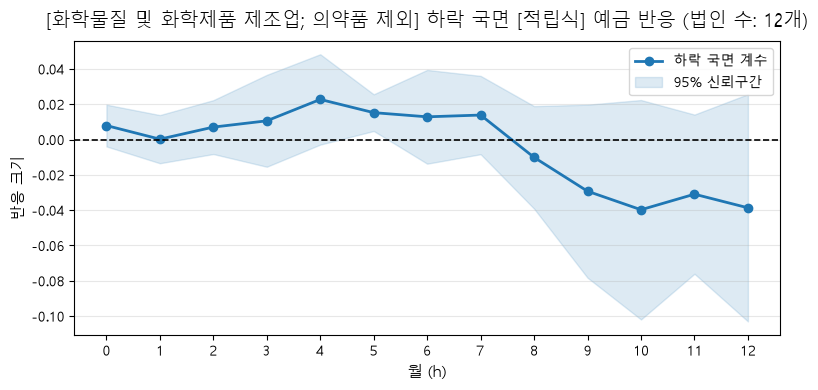

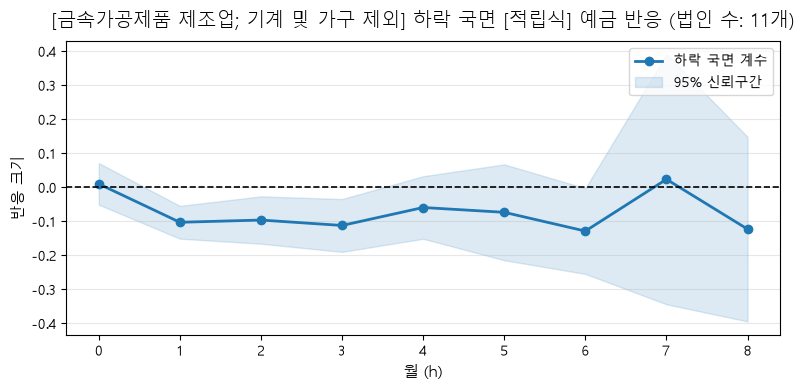

In [ ]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def plot_lp_results(res_df, title, color='tab:red'):
    if res_df.empty:
        return
    plt.figure(figsize=(8, 4))
    ci_upper = res_df['coef'] + 1.96 * res_df['se']
    ci_lower = res_df['coef'] - 1.96 * res_df['se']
    
    plt.plot(res_df['h'], res_df['coef'], marker='o', color=color, linewidth=2, label='하락 국면 계수')
    plt.fill_between(res_df['h'], ci_lower, ci_upper, color=color, alpha=0.15, label='95% 신뢰구간')
    
    plt.axhline(0, color='black', linestyle='--', linewidth=1.2)
    plt.title(title, fontsize=14, pad=10)
    plt.xlabel('월 (h)', fontsize=11)
    plt.ylabel('반응 크기', fontsize=11)
    plt.xticks(res_df['h'])
    plt.grid(True, axis='y', alpha=0.3)
    plt.legend(loc='upper right', fontsize=10)
    plt.tight_layout()
    plt.show()

# ==========================================
# 6. 기획서 검증용 업종별 분할 분석 (거치식 & 적립식)
# ==========================================
target_industries = [
    '도매 및 상품 중개업', '기타 기계 및 장비 제조업', '섬유제품 제조업; 의복제외', 
    '자동차 및 트레일러 제조업', '1차 금속 제조업', '화학물질 및 화학제품 제조업; 의약품 제외',
    '금속가공제품 제조업; 기계 및 가구 제외', '식료품 제조업', 
    '전자부품, 컴퓨터, 영상, 음향 및 통신장비 제조업', '고무 및 플라스틱제품 제조업'
]

summary_time = []
summary_install = []
results_time = {}
results_install = {}

for ind in target_industries:
    # --- 거치식 예금 분석 ---
    df_ind_time = df_time[df_time['업종_중분류'] == ind].copy()
    n_firms_time = df_ind_time.index.get_level_values('법인ID').nunique()
    
    if n_firms_time >= 5: 
        res_ind_time = run_local_projections_asymmetry_panel(df_ind_time, 'log_거치식', 'export_shock', max_h=12)
        if not res_ind_time.empty:
            results_time[ind] = {'df': res_ind_time, 'n_firms': n_firms_time}
            row = {'업종명': ind, '법인수': n_firms_time}
            for h in [3, 6, 12]:
                h_data = res_ind_time[res_ind_time['h'] == h]
                if not h_data.empty:
                    coef = h_data['coef'].values[0]
                    pval = h_data['p_value_interaction'].values[0]
                    star = '**' if pval < 0.05 else ('*' if pval < 0.1 else '')
                    row[f'h={h} 계수'] = f"{coef:.4f} {star}"
                    row[f'h={h} p-value'] = f"{pval:.3f}"
            summary_time.append(row)

    # --- 적립식 예금 분석 ---
    df_ind_install = df_install[df_install['업종_중분류'] == ind].copy()
    n_firms_install = df_ind_install.index.get_level_values('법인ID').nunique()
    
    if n_firms_install >= 5: 
        res_ind_install = run_local_projections_asymmetry_panel(df_ind_install, 'log_적립식', 'export_shock', max_h=12)
        if not res_ind_install.empty:
            results_install[ind] = {'df': res_ind_install, 'n_firms': n_firms_install}
            row = {'업종명': ind, '법인수': n_firms_install}
            for h in [3, 6, 12]:
                h_data = res_ind_install[res_ind_install['h'] == h]
                if not h_data.empty:
                    coef = h_data['coef'].values[0]
                    pval = h_data['p_value_interaction'].values[0]
                    star = '**' if pval < 0.05 else ('*' if pval < 0.1 else '')
                    row[f'h={h} 계수'] = f"{coef:.4f} {star}"
                    row[f'h={h} p-value'] = f"{pval:.3f}"
            summary_install.append(row)

# 표 출력
print("\n[업종별 하락 국면 거치식 예금 반응 요약표 (* p<0.1, ** p<0.05)]")
print("-" * 80)
print(pd.DataFrame(summary_time).to_string(index=False))
print("-" * 80)

print("\n[업종별 하락 국면 적립식 예금 반응 요약표 (* p<0.1, ** p<0.05)]")
print("-" * 80)
print(pd.DataFrame(summary_install).to_string(index=False))
print("-" * 80)

# 시각화 루프 실행
print("\n[업종별 충격반응함수(IRF) 시각화 - 거치식 예금]")
for ind, data in results_time.items():
    plot_lp_results(data['df'], f"[{ind}] 하락 국면 [거치식] 예금 반응 (법인 수: {data['n_firms']}개)", color='tab:red')

print("\n[업종별 충격반응함수(IRF) 시각화 - 적립식 예금]")
for ind, data in results_install.items():
    plot_lp_results(data['df'], f"[{ind}] 하락 국면 [적립식] 예금 반응 (법인 수: {data['n_firms']}개)", color='tab:blue')